# 6CS012 Worksheet 2 — Image Classification Using Softmax Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

print("All imports successful!")

All imports successful!


---
## Section 3.1 — Decision Function

### 3.1.1 Softmax Function

The softmax function converts a vector of raw scores (logits) into a probability distribution:


In [ ]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
        z (numpy.ndarray): Logits (raw scores) of shape (m, n), where
            - m is the number of samples.
            - n is the number of classes.

    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n), where
            each row sums to 1 and represents the probability
            distribution over classes.

    Notes:
        - The input to softmax is typically computed as: z = XW + b.
        - Uses numerical stabilization by subtracting the max value per row.
    """
    # Subtract max per row for numerical stability (avoids overflow)
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:


z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])

softmax_output = softmax(z_test)

# Verify if the sum of probabilities for each row is 1 using assert
row_sums = np.sum(softmax_output, axis=1)

# Assert that the sum of each row is 1
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax function passed the test case!")
print(f"Softmax output:\n{softmax_output}")
print(f"Row sums: {row_sums}")

Softmax function passed the test case!
Softmax output:
[[0.65900114 0.24243297 0.09856589]
 [0.33333333 0.33333333 0.33333333]]
Row sums: [1. 1.]


### 3.1.2 Prediction Function



In [ ]:
def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d), where n is the number
                           of samples and d is the number of features.
        W (numpy.ndarray): Weight matrix of shape (d, c), where c is the number of classes.
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        numpy.ndarray: Predicted class labels of shape (n,), where each value is
                       the index of the predicted class.
    """
    # Compute logits: z = XW + b  →  shape (n, c)
    z = np.dot(X, W) + b
    # Compute softmax probabilities
    probs = softmax(z)           # shape (n, c)
    # Choose the class with the highest probability for each sample
    predicted_classes = np.argmax(probs, axis=1)   # shape (n,)
    return predicted_classes

In [ ]:


# Define test case
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

# Expected Output:
# The function should return an array with class labels (0, 1, or 2)
y_pred_test = predict_softmax(X_test, W_test, b_test)

# Validate output shape
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"

# Print the predicted labels
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


---
## Section 3.2 — Loss and Cost Functions

### 3.2.1 Categorical Cross-Entropy Loss



In [ ]:
def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss for a single sample (or batch).

    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities of shape (n, c) or (c,),
                                where c is the number of classes.
        y     (numpy.ndarray): True labels (one-hot encoded) of shape (n, c) or (c,).

    Returns:
        float: Cross-entropy loss.
    """
    # Clip predictions to avoid log(0)
    epsilon = 1e-15
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)

    # Compute cross-entropy: -mean over samples of sum over classes
    loss = -np.mean(np.sum(y * np.log(y_pred_clipped), axis=1))
    return loss

In [ ]:


# Define correct predictions (low loss scenario)
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])   # True one-hot labels
y_pred_correct = np.array([[0.9, 0.05, 0.05],
                            [0.1, 0.85, 0.05],
                            [0.05, 0.1, 0.85]])                   # High confidence in the correct class

# Define incorrect predictions (high loss scenario)
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],   # Highly confident in the wrong class
                              [0.1, 0.05, 0.85],
                              [0.85, 0.1, 0.05]])

# Compute loss for both cases
loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

# Validate that incorrect predictions lead to a higher loss
assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, "
    f"but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
)

# Print results
print(f"Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


### 3.2.2 Cost Function

The cost function averages the cross-entropy loss across all samples in a dataset, given model parameters **(W, b)**.

In [ ]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        float: Average softmax cost (cross-entropy loss) over all samples.
    """
    n = X.shape[0]                    # Number of samples

    # Forward pass: compute predicted probabilities
    z = np.dot(X, W) + b              # Logits  →  shape (n, c)
    y_pred = softmax(z)               # Probabilities  →  shape (n, c)

    # Clip to avoid log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Sum of cross-entropy over all samples and classes
    total_loss = -np.sum(y * np.log(y_pred))

    # Return average loss
    return total_loss / n

In [ ]:
#  Cost Function Test Case (DO NOT MODIFY)
# The test case assures that the cost for the incorrect prediction should be
# higher than for the correct prediction.

# Example 1: Correct Prediction (Closer predictions)
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])        # Feature matrix
y_correct = np.array([[1, 0], [0, 1]])                  # True labels (one-hot encoded)
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])       # Weights
b_correct = np.array([0.1, 0.1])                        # Bias

# Example 2: Incorrect Prediction (Far off predictions)
X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])       # Feature matrix
y_incorrect = np.array([[1, 0], [0, 1]])                # True labels
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])       # Weights
b_incorrect = np.array([0.5, 0.6])                      # Bias

# Compute cost for correct predictions
cost_correct   = cost_softmax(X_correct,   y_correct,   W_correct,   b_correct)
# Compute cost for incorrect predictions
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

# Check if the cost for incorrect predictions is greater than for correct predictions
assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)

# Print the costs for verification
print("Cost for correct prediction:",   cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


---
## Section 3.3 — Gradient Descent

### 3.3.1 Compute Gradients

The gradients of the categorical cross-entropy loss w.r.t. **W** and **b** are:

$$\frac{\partial \mathcal{L}}{\partial W} = \frac{1}{n} X^\top (\hat{Y} - Y)$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

In [ ]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function with respect to weights and biases.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        tuple: Gradients with respect to weights (d, c) and biases (c,).
    """
    n = X.shape[0]                      # Number of samples

    # Forward pass: compute predicted probabilities
    z      = np.dot(X, W) + b           # Logits  →  shape (n, c)
    y_pred = softmax(z)                 # Probabilities  →  shape (n, c)

    # Residuals: difference between predictions and true labels
    residuals = y_pred - y              # shape (n, c)

    # Gradient w.r.t. W:  X^T · residuals / n   →  shape (d, c)
    grad_W = np.dot(X.T, residuals) / n

    # Gradient w.r.t. b:  mean of residuals over samples  →  shape (c,)
    grad_b = np.sum(residuals, axis=0) / n

    return grad_W, grad_b

In [ ]:
# ── Gradient Test Case (DO NOT MODIFY)

# Define a simple feature matrix and true labels
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

# Define weight matrix and bias vector
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

# Compute the gradients using the function
grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

# Manually compute the predicted probabilities (using softmax function)
z_test       = np.dot(X_test, W_test) + b_test
y_pred_test  = softmax(z_test)

# Compute the manually computed gradients
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

# Assert that the gradients computed by the function match the manually computed gradients
assert np.allclose(grad_W, grad_W_manual), (
    f"Test failed: Gradients w.r.t. W are not equal.\nExpected: {grad_W_manual}\nGot: {grad_W}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: Gradients w.r.t. b are not equal.\nExpected: {grad_b_manual}\nGot: {grad_b}"
)

# Print the gradients for verification
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


### 3.3.2 Gradient Descent Algorithm

We iteratively update parameters:

$$W \leftarrow W - \alpha \cdot \frac{\partial \mathcal{L}}{\partial W}, \qquad b \leftarrow b - \alpha \cdot \frac{\partial \mathcal{L}}{\partial b}$$

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.

    Parameters:
        X         (numpy.ndarray): Feature matrix of shape (n, d).
        y         (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W         (numpy.ndarray): Weight matrix of shape (d, c).
        b         (numpy.ndarray): Bias vector of shape (c,).
        alpha     (float)        : Learning rate.
        n_iter    (int)          : Number of iterations.
        show_cost (bool)         : Whether to display the cost at intervals.

    Returns:
        tuple: Optimized weights, biases, and cost history.
    """
    cost_history = []

    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update parameters in the direction of the negative gradient
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Record the cost at this iteration
        current_cost = cost_softmax(X, y, W, b)
        cost_history.append(current_cost)

        # Optionally print progress every 100 iterations
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i:4d} | Cost: {current_cost:.6f}")

    return W, b, cost_history

---
## Section 3.4 — Preparing the Dataset

### Question 1: Is extracting pixel values sufficient for effective feature extraction? Why or why not?

Answer:
Extracting raw pixel values is a valid starting point but is **not sufficient** for truly effective feature extraction. Here is why:

1. **High dimensionality with low information density** — A 28×28 image gives 784 features. Many of these are redundant or carry little useful discriminative information (e.g., corner pixels are almost always zero for MNIST). This can hurt both training efficiency and generalisation.

2. **No spatial invariance** — Raw pixel values are sensitive to translation, rotation, and scale. A digit '3' shifted two pixels to the right looks very different to the model but is the same digit to a human. Convolutional Neural Networks (CNNs) address this by learning spatially invariant features via shared filter weights.

3. **No structural encoding** — Pixels do not capture edges, curves, or strokes — the higher-level structures that actually distinguish digits. Feature extraction methods such as HOG (Histogram of Oriented Gradients) or learned CNN features explicitly encode these structural patterns.

4. **Sensitivity to noise** — Raw pixels are directly affected by lighting variation, ink thickness, and scanning artefacts. Normalisation (dividing by 255) helps somewhat, but engineered or learned features are inherently more robust.

5. **MNIST is a special case** — For MNIST specifically, raw pixels with normalisation *do* work reasonably well with linear classifiers because the dataset is carefully preprocessed (centred, size-normalised). On real-world image datasets, raw pixels perform poorly compared to learned representations.

**Conclusion:** For MNIST, raw pixel extraction with normalisation is a good baseline. For more complex tasks, more sophisticated feature extraction (e.g., CNN representations, SIFT, HOG) significantly improves accuracy.

Loading MNIST via sklearn (fetch_openml) — this may take a moment...
Training set: (56000, 784), Test set: (14000, 784)


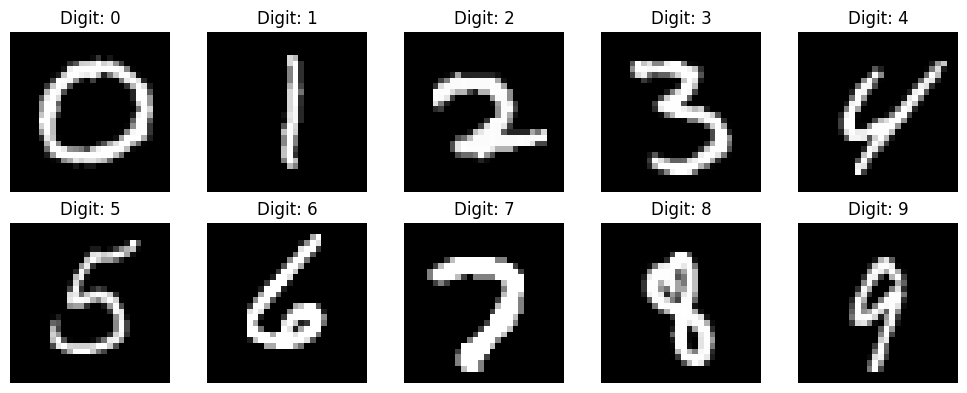

In [ ]:
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).

    Arguments:
        X (np.ndarray): Feature matrix containing pixel values.
        y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)   # Get unique class labels
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]      # Find first occurrence of the class
        image = X[index].reshape(28, 28)         # Reshape 1D array to 28×28
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets, and
    plots one image per class.

    Arguments:
        csv_file     (str)  : Path to the CSV file containing MNIST data.
        test_size    (float): Proportion of data to use as test set (default: 0.2).
        random_state (int)  : Random seed for reproducibility (default: 42).

    Returns:
        X_train, X_test, y_train, y_test : Split dataset.
    """
    # Load dataset
    df = pd.read_csv("/content/drive/MyDrive/Semester6_AI ML/mnist_dataset.csv")

    # Separate labels and features
    y = df.iloc[:, 0].values    # First column is the label
    X = df.iloc[:, 1:].values   # Remaining columns are pixel values

    # Normalize pixel values (optional but recommended)
    X = X / 255.0               # Scale values between 0 and 1

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Plot one sample image per class
    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test



from sklearn.datasets import fetch_openml

print("Loading MNIST via sklearn (fetch_openml) — this may take a moment...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all = mnist.data.astype(np.float64) / 255.0     # Normalise
y_all = mnist.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Visualise one sample per digit
plot_sample_images(X_train, y_train)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Section 3.5 — Training the Model

Move forward: Dimension of Feature Matrix X and label vector y matched.

Training Softmax Regression via Gradient Descent...
Iteration    0 | Cost: 2.207086
Iteration  100 | Cost: 0.603732
Iteration  200 | Cost: 0.486001
Iteration  300 | Cost: 0.437384
Iteration  400 | Cost: 0.409306
Iteration  500 | Cost: 0.390453
Iteration  600 | Cost: 0.376654
Iteration  700 | Cost: 0.365977
Iteration  800 | Cost: 0.357386
Iteration  900 | Cost: 0.350272
Iteration  999 | Cost: 0.344306


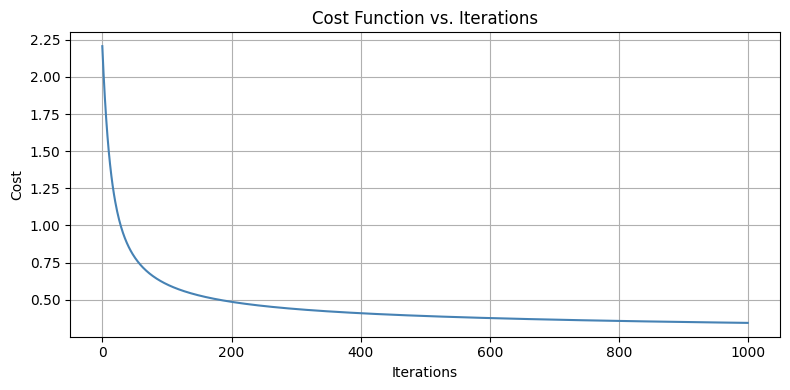

In [ ]:
#  Shape Check Before Training
assert len(X_train) == len(y_train), (
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
)
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

#  One-Hot Encode Labels
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train_ohe = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test_ohe  = encoder.transform(y_test.reshape(-1, 1))
else:
    y_train_ohe = y_train
    y_test_ohe  = y_test

d = X_train.shape[1]          # Number of features
c = y_train_ohe.shape[1]      # Number of classes (10 digits)

#  Initialise Parameters
np.random.seed(0)
W = np.random.randn(d, c) * 0.01   # Small random weights
b = np.zeros(c)                     # Bias initialised to 0

# Hyperparameters
alpha  = 0.1     # Learning rate
n_iter = 1000    # Number of gradient-descent iterations

#  Train the Model
print("\nTraining Softmax Regression via Gradient Descent...")
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train_ohe, W, b, alpha, n_iter, show_cost=True
)

#  Plot Cost History
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color='steelblue')
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Section 3.6 — Evaluating Model Performance

In [ ]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix,
    precision, recall, and F1-score.

    Parameters:
        y_true (numpy.ndarray): True labels
        y_pred (numpy.ndarray): Predicted labels

    Returns:
        tuple: Confusion matrix, precision, recall, F1 score
    """
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1


Confusion Matrix:
[[1294    0    4    2    1   11   16    2   11    2]
 [   0 1547    3   12    1    9    1    6   18    3]
 [   5   20 1206   17   24    7   31   25   38    7]
 [   3    9   29 1266    0   53   14   16   25   18]
 [   1    5   13    2 1180    0   13    5    8   68]
 [  13   15    7   61   22 1069   16    6   48   16]
 [   3    4   18    4   16   21 1318    1   10    1]
 [  10   19   25    5   13    3    0 1385    3   40]
 [   8   36   19   52    9   37   16   11 1148   21]
 [  10   10    9   17   49   11    0   48   13 1253]]
Precision : 0.90
Recall    : 0.90
F1-Score  : 0.90


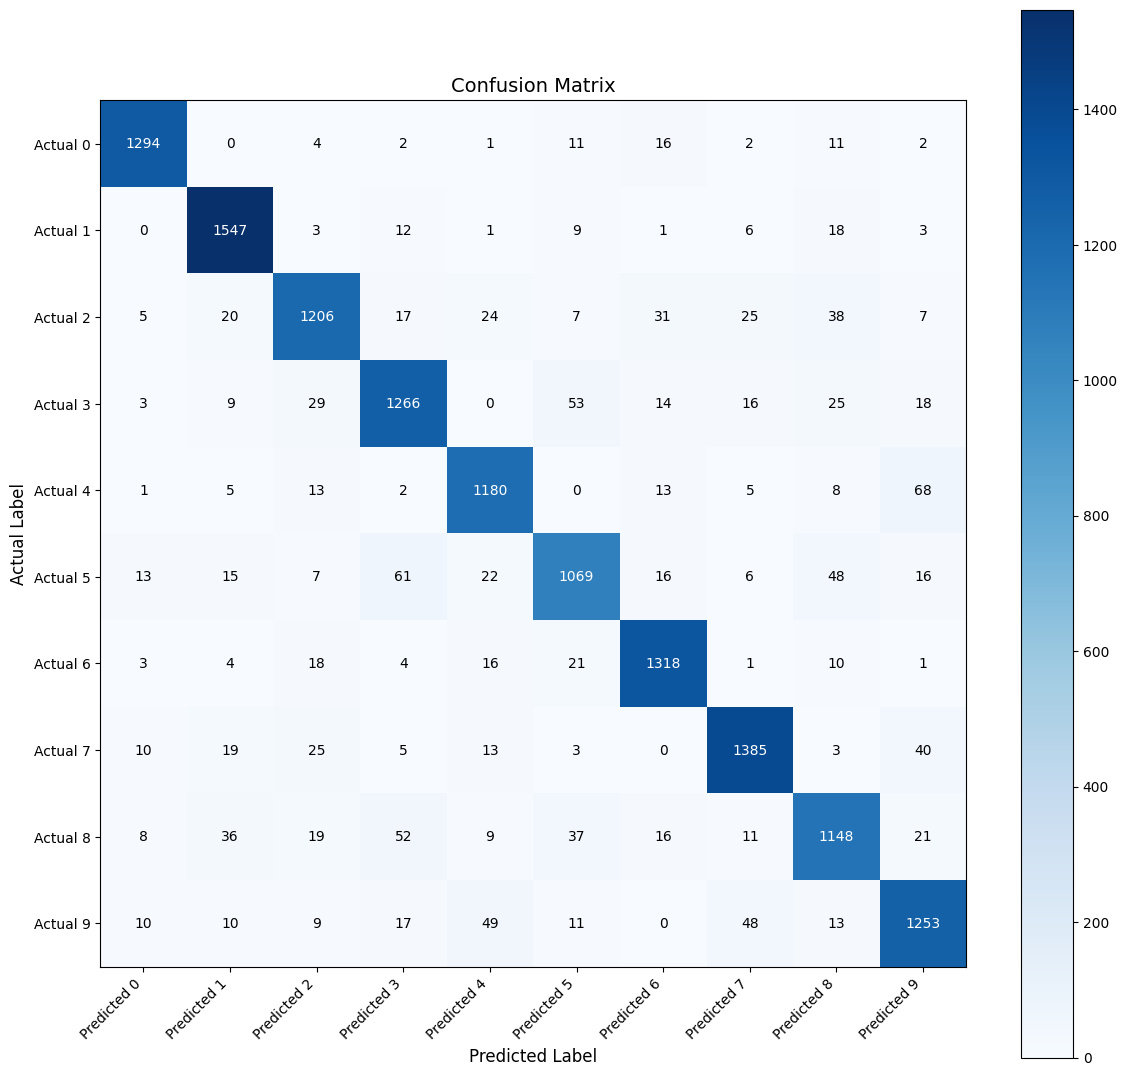

In [ ]:
# ── Predict on the Test Set
y_pred_test   = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test_ohe, axis=1)    # True labels in numeric form

# ── Evaluate the Model ─────
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")

# ── Visualise the Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)], rotation=45, ha='right')
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

---
## Section 4 — Linear Separability and Logistic Regression

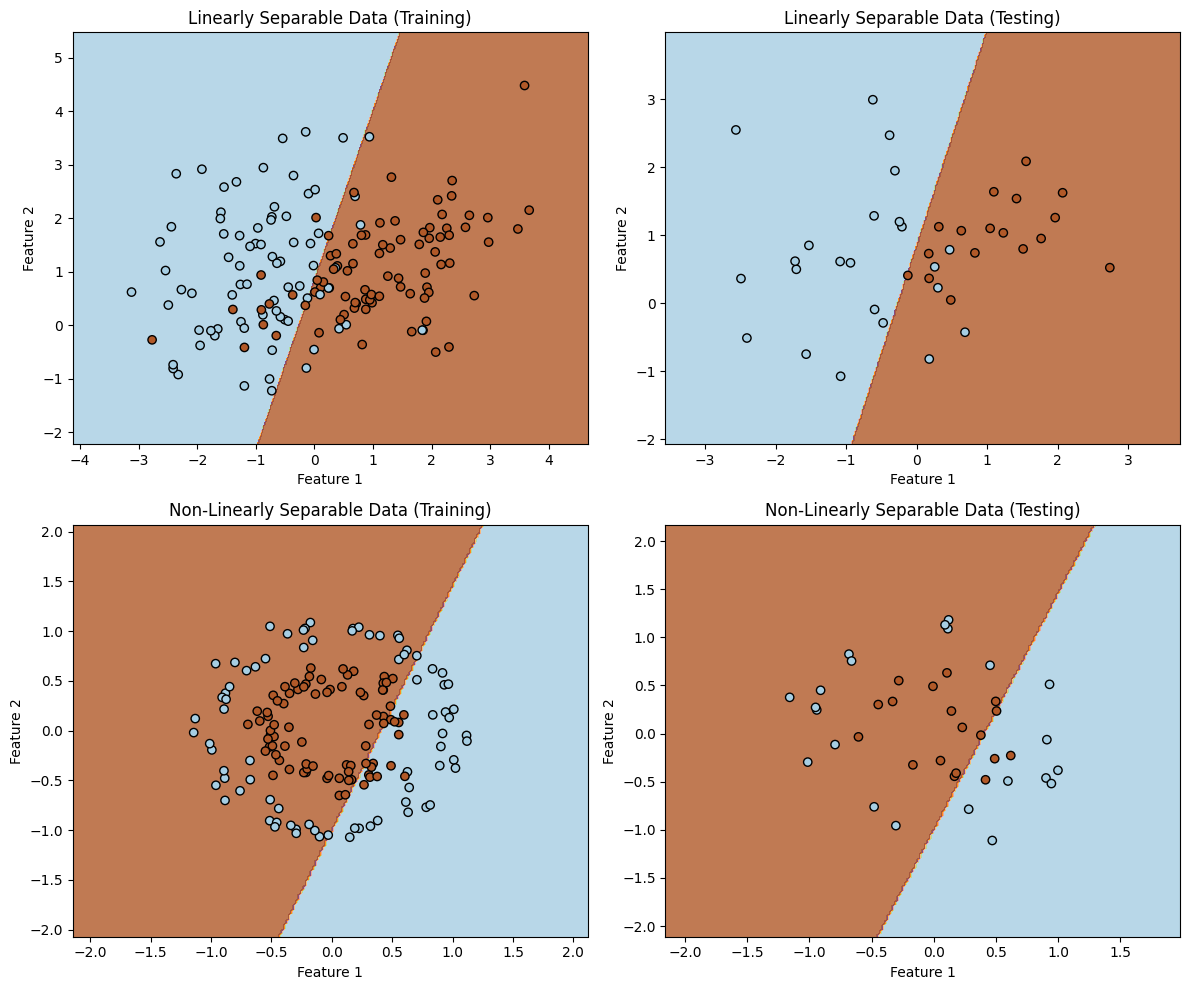

In [ ]:
np.random.seed(42)

#  Generate Linearly Separable Dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

#  Generate Non-Linearly Separable Dataset (Circles)
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

#  Decision Boundary Plotting Function
def plot_decision_boundary(ax, model, X, y, title):
    h = .02   # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

#  Create Subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(axes[0, 0], logistic_model_linear_separable,
                       X_train_linear, y_train_linear,
                       'Linearly Separable Data (Training)')

plot_decision_boundary(axes[0, 1], logistic_model_linear_separable,
                       X_test_linear, y_test_linear,
                       'Linearly Separable Data (Testing)')

plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable,
                       X_train_non_linear, y_train_non_linear,
                       'Non-Linearly Separable Data (Training)')

plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable,
                       X_test_non_linear, y_test_non_linear,
                       'Non-Linearly Separable Data (Testing)')

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

### Question 2: Provide an interpretation of the output based on your understanding.

**Answer:**

The four plots reveal a fundamental limitation of linear classifiers like Logistic Regression.

**Top row — Linearly Separable Data:**
The decision boundary is a straight line, and both training and testing plots show the two classes cleanly separated on either side. The background colouring shows that the model has learned a single linear boundary that correctly partitions the feature space. Accuracy on both sets should be high (typically > 90%), and the boundary in the test plot looks very similar to the training plot, indicating the model generalises well — there is minimal overfitting because the problem is inherently linear.

**Bottom row — Non-Linearly Separable Data (Circles):**
The classes form concentric circles — the inner circle belongs to one class and the outer ring to the other. A straight-line boundary cannot separate these classes. Despite this, Logistic Regression still draws a linear boundary, resulting in many misclassifications. The decision boundary cuts through both classes without capturing the circular structure. The training and testing plots look similarly poor, confirming the model is underfitting (high bias) rather than overfitting — it fundamentally cannot represent the true decision boundary with a linear function.

**Key Takeaway:** Logistic Regression is a *linear* classifier. It performs well when classes are linearly separable but fails when the true boundary is non-linear. To handle non-linear problems, one can use:
- Feature engineering (e.g., adding polynomial or radial basis features)
- Kernel methods (e.g., Kernel SVM with RBF kernel)
- Neural networks / Deep learning

---

### Question 3: Describe any challenges you faced while implementing the code above.

**Answer:**

1. **Numerical stability in Softmax** — The naïve computation of `exp(z) / sum(exp(z))` can produce `inf` values when logits are large (overflow). The fix is to subtract `max(z)` per row before exponentiation. This trick does not change the mathematical result (since the constant cancels out) but prevents overflow, which would otherwise cause `NaN` losses.

2. **Log of zero in cross-entropy** — When `log(y_pred)` is evaluated and a predicted probability is exactly 0 (which can happen after softmax with extreme logit differences), the result is `-inf`. Clipping predictions to the range `[epsilon, 1 - epsilon]` before taking the log resolves this.

3. **Shape mismatches** — Keeping track of matrix dimensions is crucial: `X` is `(n, d)`, `W` is `(d, c)`, `b` is `(c,)`, and `y` is `(n, c)`. A common pitfall is applying `np.dot` with the wrong transpose, producing silently incorrect results. Verifying shapes with `assert` statements before training helps catch these early.

4. **One-hot encoding requirement** — The gradient and loss formulas assume `y` is one-hot encoded. Forgetting to encode labels (leaving them as integer class indices) would give wrong gradient shapes and incorrect losses.

5. **Slow convergence on the full MNIST dataset** — With 56,000 training samples and 784 features, each gradient-descent step involves a full matrix multiplication over the entire dataset (batch gradient descent). This is computationally expensive. In practice, mini-batch or stochastic gradient descent would be used to speed up training.